## This notebook reports the plots and summary statistics of the variables in the observed dataset.

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import skew, kurtosis

In [3]:
# import final dataset 
df = pd.read_csv('../final_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values("Date")

df

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1986-02-01,-0.001030,-0.001919,0.029004,-0.122803,-0.005468,-0.01,0.003518,0.000302,-0.394190
1,1986-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.003663,-0.50,0.007092,0.003699,-0.203766
2,1986-04-01,0.020833,-0.009353,0.060724,0.005213,0.001811,-0.50,-0.001419,0.001697,0.018075
3,1986-05-01,0.006006,-0.008792,0.009556,0.067115,0.006429,0.09,0.005246,0.000797,0.180503
4,1986-06-01,-0.054147,0.010266,-0.037406,0.144931,0.000907,0.06,-0.003911,-0.002716,-0.135577
...,...,...,...,...,...,...,...,...,...,...
475,2025-09-01,0.015662,0.002685,-0.003248,-0.015405,-0.000530,-0.20,0.002021,0.001084,-0.013973
476,2025-10-01,-0.007722,0.011027,-0.020480,-0.008821,-0.000530,-0.10,0.000990,-0.000535,-0.049189
477,2025-11-01,-0.006912,0.004884,-0.019770,-0.002464,-0.000530,-0.04,-0.003364,-0.002283,-0.013725
478,2025-12-01,0.021442,-0.018762,0.023579,-0.023312,-0.000530,-0.19,0.003410,0.002887,-0.035418


In [4]:
# summary statistics of the dataset
def summary_stats_table(df, cols, autocorr_lag=1):
    summary = pd.DataFrame(index=cols)

    summary["Mean"] = df[cols].mean()
    summary["Standard deviation"] = df[cols].std()
    summary["Skewness"] = df[cols].apply(skew)
    summary["Kurtosis"] = df[cols].apply(kurtosis)  # excess kurtosis
    summary["Minimum"] = df[cols].min()
    summary["Maximum"] = df[cols].max()
    summary["Auto-correlation"] = df[cols].apply(lambda x: x.autocorr(lag=autocorr_lag))

    return summary

In [5]:
cols = [col for col in df.columns if col != "Date"]

summary_df = summary_stats_table(df, cols)
summary_df.index.name = "Variable"
summary_df.columns = [
    "Mean", "Standard deviation", "Skewness",
    "Kurtosis", "Minimum", "Maximum", "Auto-correlation"
]
summary_df = summary_df.iloc[::-1].reset_index(drop=False)
summary_df

,Variable,Mean,Standard deviation,Skewness,Kurtosis,Minimum,Maximum,Auto-correlation
0,wti_ret,0.002005,0.095973,-0.648514,7.456322,-0.568125,0.545621,0.262747
1,M2,-0.000001,0.004426,-0.260772,15.587648,-0.032606,0.030069,-0.161096
2,M1,0.000006,0.074866,-1.929930,227.314320,-1.192866,1.094238,-0.471674
3,TB3MS,-0.007292,0.193571,-1.101276,5.643868,-1.230000,0.740000,0.498989
4,CPI,-0.000007,0.002734,-0.396524,3.254513,-0.012632,0.010795,-0.160424
5,ZAR_USD_ret,0.004019,0.034216,0.748970,4.517491,-0.122803,0.191525,0.293132
6,NZD_USD_ret,0.000259,0.025717,-0.172833,0.657338,-0.103432,0.073986,0.284390
7,CAD_USD_ret,-0.000045,0.015914,0.527090,5.536594,-0.060092,0.112912,0.269332
8,AUD_USD_ret,-0.000063,0.025271,-0.893161,4.518054,-0.173162,0.071296,0.340869


In [6]:
# to latex table
latex_table = summary_df.to_latex(
    caption="Summary statistics for rate of growth of oil prices and predictor variables.",
    label="tab:summary_stats",
    column_format="lrrrrrrr"
)

print(latex_table)

\begin{table}
\centering
\caption{Summary statistics for rate of growth of oil prices and predictor variables.}
\label{tab:summary_stats}
\begin{tabular}{lrrrrrrr}
\toprule
{} &     Variable &      Mean &  Standard deviation &  Skewness &    Kurtosis &   Minimum &   Maximum &  Auto-correlation \\
\midrule
0 &      wti\_ret &  0.002005 &            0.095973 & -0.648514 &    7.456322 & -0.568125 &  0.545621 &          0.262747 \\
1 &           M2 & -0.000001 &            0.004426 & -0.260772 &   15.587648 & -0.032606 &  0.030069 &         -0.161096 \\
2 &           M1 &  0.000006 &            0.074866 & -1.929930 &  227.314320 & -1.192866 &  1.094238 &         -0.471674 \\
3 &        TB3MS & -0.007292 &            0.193571 & -1.101276 &    5.643868 & -1.230000 &  0.740000 &          0.498989 \\
4 &          CPI & -0.000007 &            0.002734 & -0.396524 &    3.254513 & -0.012632 &  0.010795 &         -0.160424 \\
5 &  ZAR\_USD\_ret &  0.004019 &            0.034216 &  0.748970 &    4.

/var/folders/2h/gvrjdw1x6t766jgk66w62_tw0000gn/T/ipykernel_12876/3344452126.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = summary_df.to_latex(


In [7]:
cols = [
    "AUD_USD_ret", "CAD_USD_ret", "NZD_USD_ret",
    "ZAR_USD_ret", "CPI", "TB3MS",
    "M1", "M2", "wti_ret"
]


pretty_names = {
    "AUD_USD_ret": "AUD/USD Returns",
    "CAD_USD_ret": "CAD/USD Returns",
    "NZD_USD_ret": "NZD/USD Returns",
    "ZAR_USD_ret": "ZAR/USD Returns",
    "CPI": "Inflation (CPI)",
    "TB3MS": "3-Month T-Bill Rate",
    "M1": "M1 Growth",
    "M2": "M2 Growth",
    "wti_ret": "WTI Returns"
}

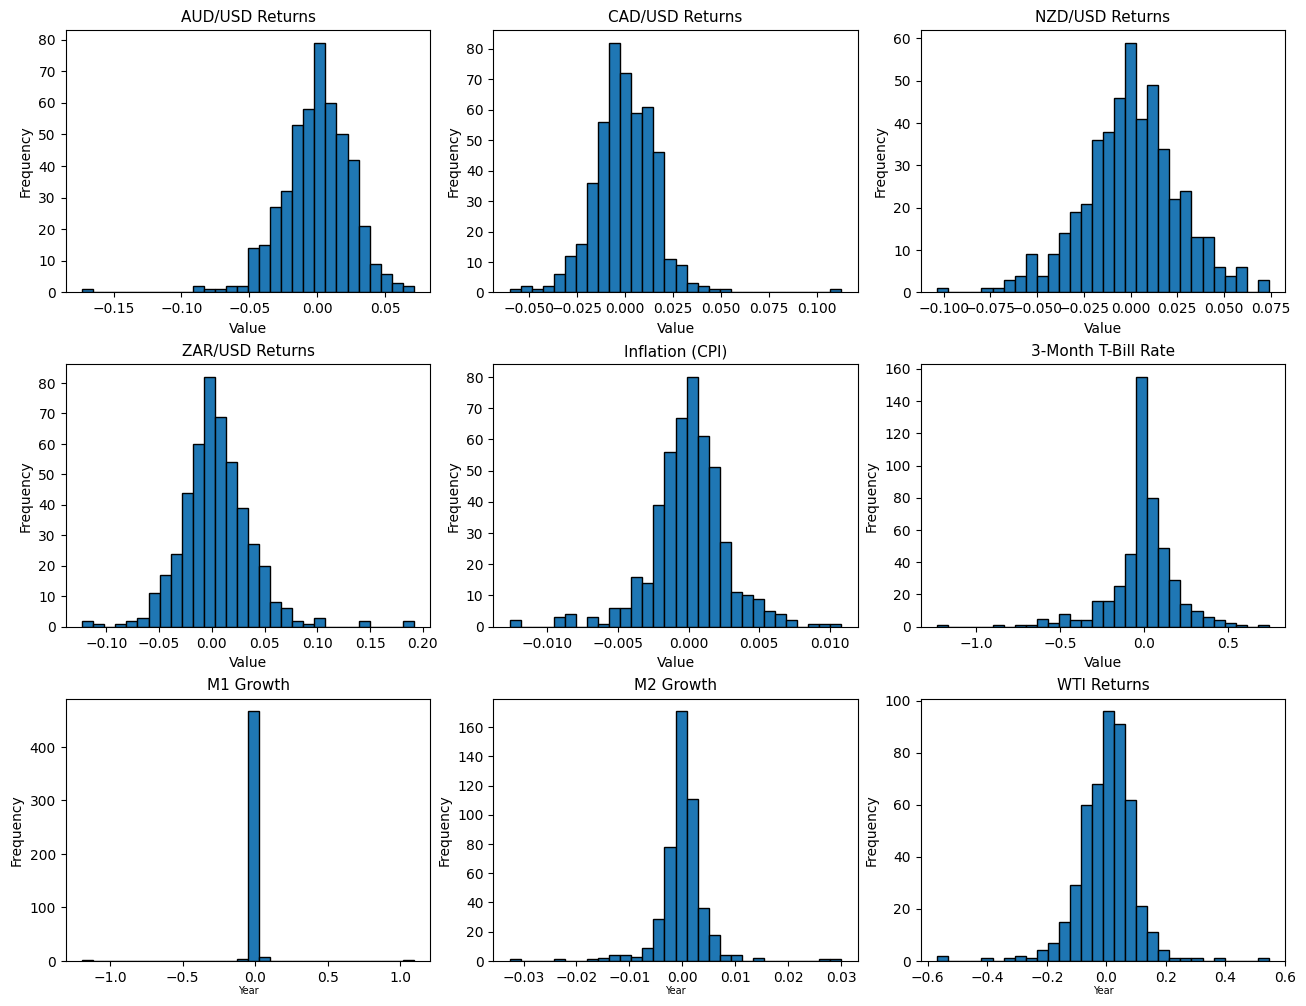

In [8]:
fig1, axes = plt.subplots(3, 3, figsize=(13, 10))

for i, col in enumerate(cols):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col].dropna(), bins=30, edgecolor="black")
    ax.set_title(pretty_names[col], fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

for ax in axes[-1, :]:
    ax.set_xlabel("Year", fontsize=7, labelpad=1)

fig1.tight_layout(pad=0.5, w_pad=0.4, h_pad=0.6)
fig1.savefig("figure1_distributions.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()


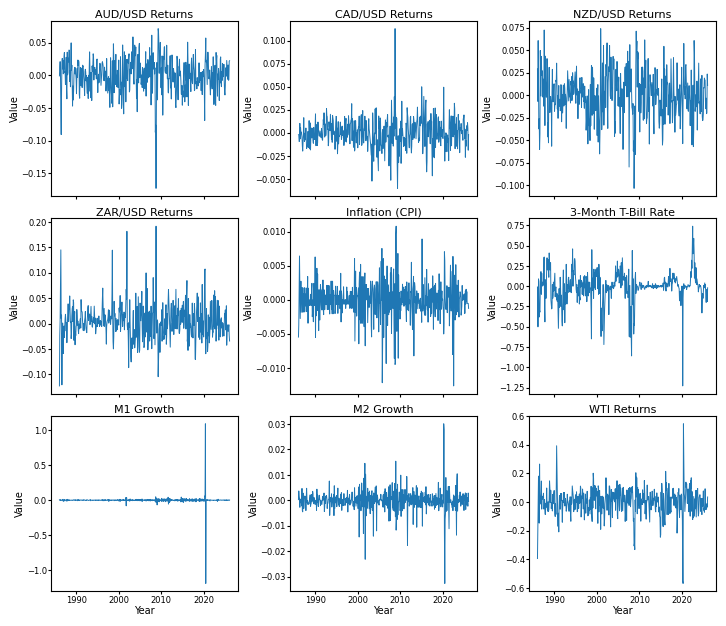

In [9]:
fig2, axes = plt.subplots(3, 3, figsize=(7.2, 6.2), sharex=True)

for i, col in enumerate(cols):
    ax = axes[i // 3, i % 3]
    ax.plot(df["Date"], df[col], linewidth=0.7)
    ax.set_title(pretty_names[col], fontsize=8, pad=2)
    ax.set_ylabel("Value", fontsize=7, labelpad=1)
    ax.tick_params(axis="both", labelsize=6, length=2, pad=1)

    ax.xaxis.set_major_locator(mdates.YearLocator(base=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for ax in axes[-1, :]:
    ax.set_xlabel("Year", fontsize=7, labelpad=1)

fig2.tight_layout(pad=0.5, w_pad=0.4, h_pad=0.6)
fig2.savefig("figure2_time_series.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()

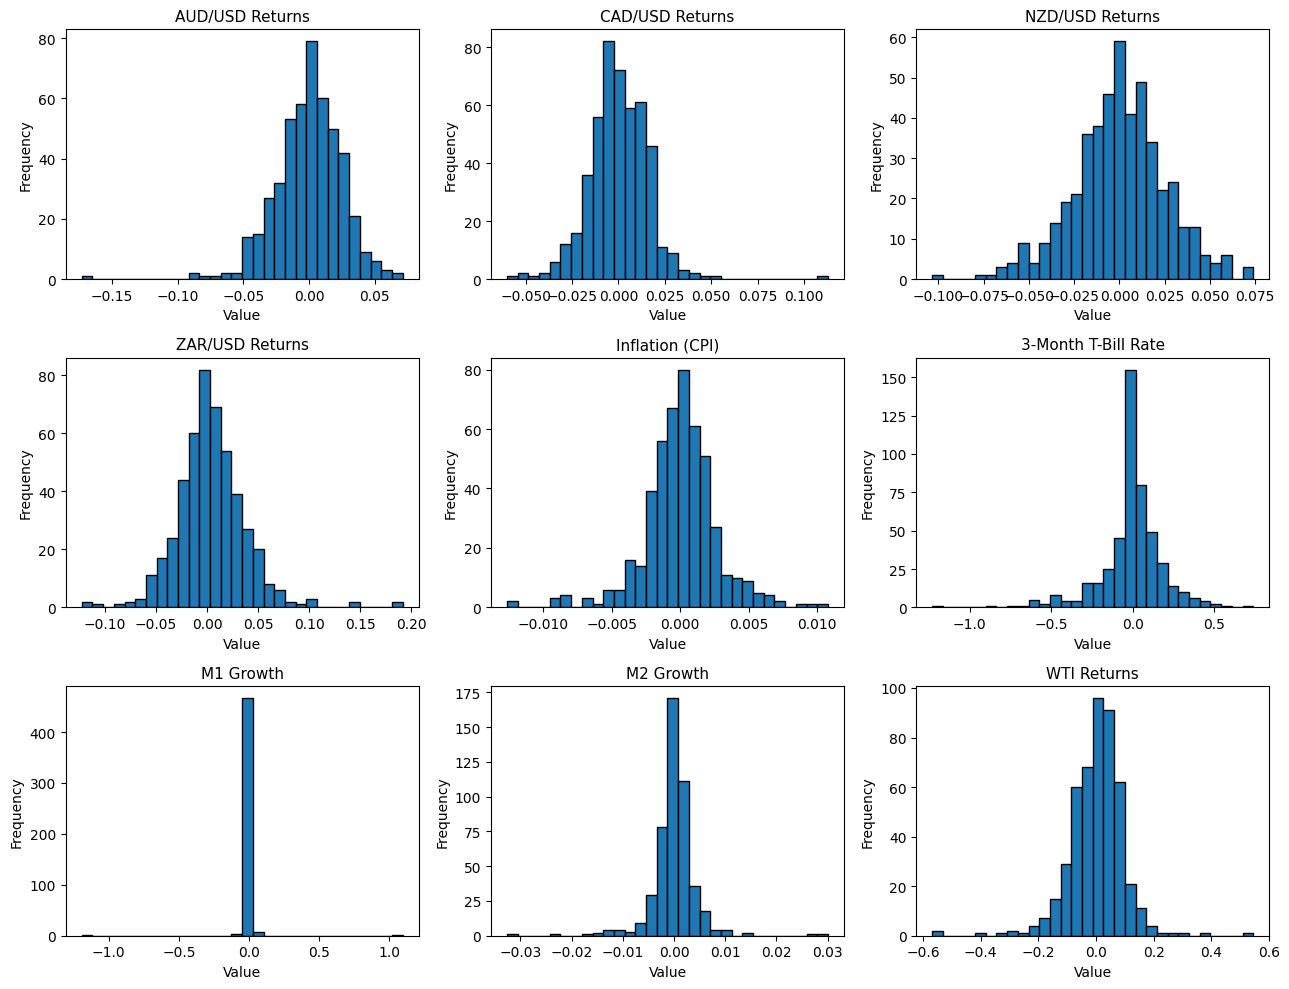

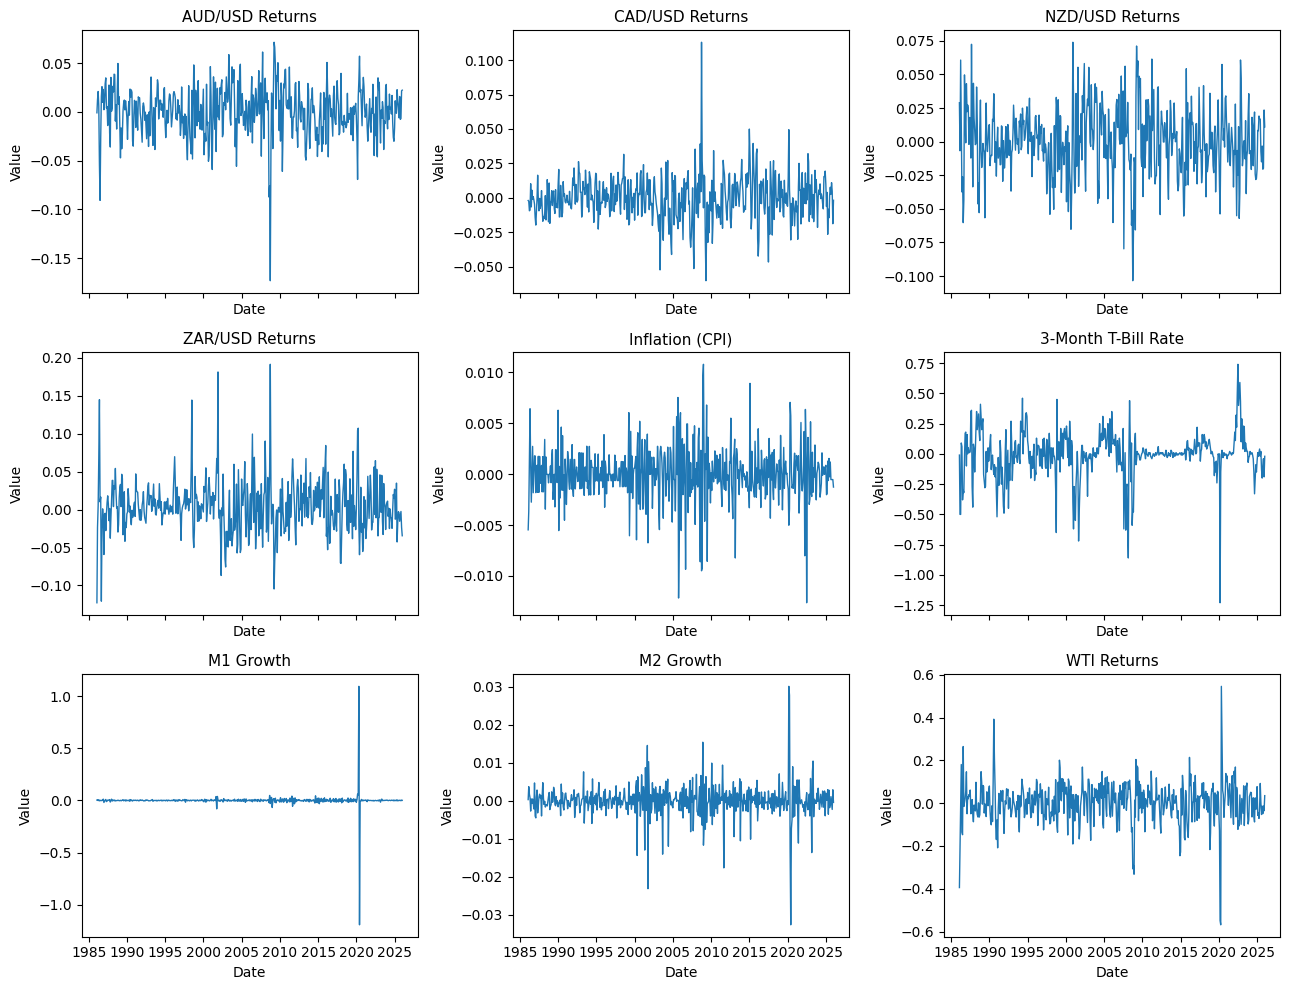

In [10]:
fig1, axes = plt.subplots(3, 3, figsize=(13, 10))
for i, col in enumerate(cols):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col].dropna(), bins=30, edgecolor="black")
    ax.set_title(pretty_names[col], fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
fig1.tight_layout()
fig1.savefig("figure1_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True)
for i, col in enumerate(cols):
    ax = axes[i // 3, i % 3]
    ax.plot(df["Date"], df[col], linewidth=1)
    ax.set_title(pretty_names[col], fontsize=11)
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
fig2.tight_layout()
fig2.savefig("figure2_time_series.png", dpi=300, bbox_inches="tight")
plt.show()

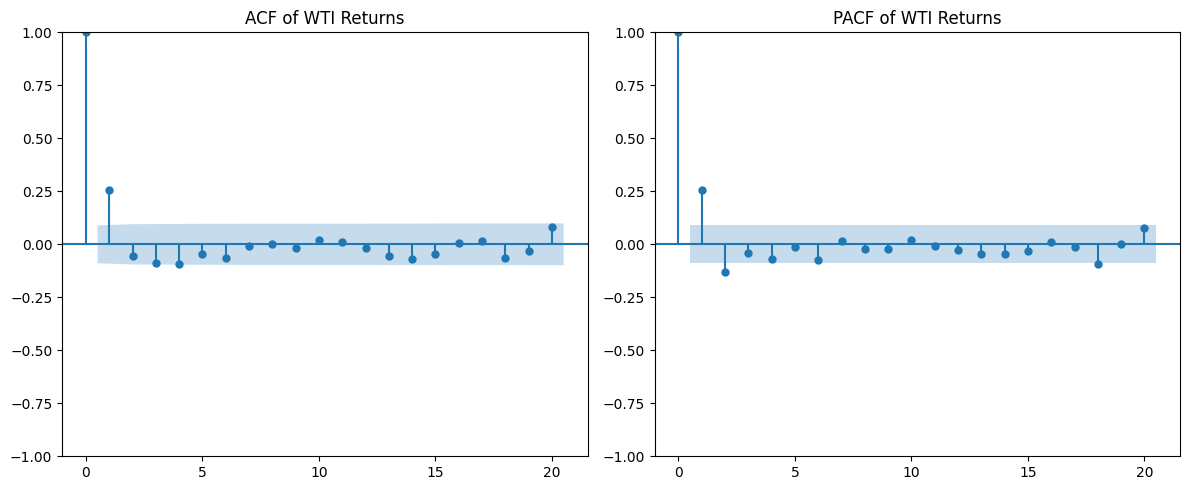

In [11]:
# acf and pacf plots for wti returns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(df['wti_ret'], lags=20, ax=plt.gca())
plt.title("ACF of WTI Returns")
plt.subplot(1, 2, 2)
plot_pacf(df['wti_ret'], lags=20, ax=plt.gca())
plt.title("PACF of WTI Returns")
plt.tight_layout()  